    Instructions:
    1. Press Run All
    2. You will be prompted for an Image ID after the dataset is downloaded.

    
    Task 1: Implement a program which, given an image ID and one of the
    following feature models, visualizes the image and then extracts and
    prints (in a human readable form) the corresponding feature descriptors:

    1. Color moments (CM10x10)
    2. Histograms of oriented gradients (HOG)
    3. ResNet-AvgPool-1024
    4. ResNet-Layer3-1024
    5. ResNet-FC-1000

In [1]:
# Initialize dataset, downloads into ./caltech101 if not present. Untracked by git.

import os
from torchvision.datasets import Caltech101

dataset = Caltech101(root=os.getcwd(), download=True)

print(dataset)

# __getitem__ returns a tuple (PIL, category number).

Files already downloaded and verified
Dataset Caltech101
    Number of datapoints: 8677
    Root location: /Users/gokulvsd/repos/ViVeC/Code/caltech101
    Target type: ['category']


Image ID:  2500


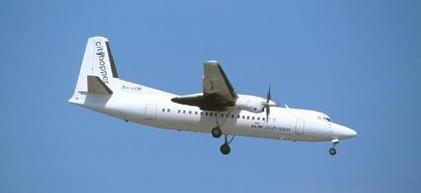

Category: airplanes


In [2]:
# Visualize an image given an image ID.

# Each category orderd alphabetically has numbered images starting from 0,
# tourchvision wraps these and concats them all sequentially.

IMG_ID = int(input("Provide an Image ID in the Caltech101 dataset in range [0, 8676]"))

image, category = dataset[IMG_ID][0], dataset.categories[dataset[IMG_ID][1]]

print("Image ID: ", IMG_ID)
display(image)
print("Category:", category)

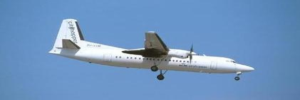

In [3]:
# Resize image to 300 x 100.

from torchvision.transforms import Resize

image300x100 = Resize(size=(100, 300))(image)

display(image300x100)

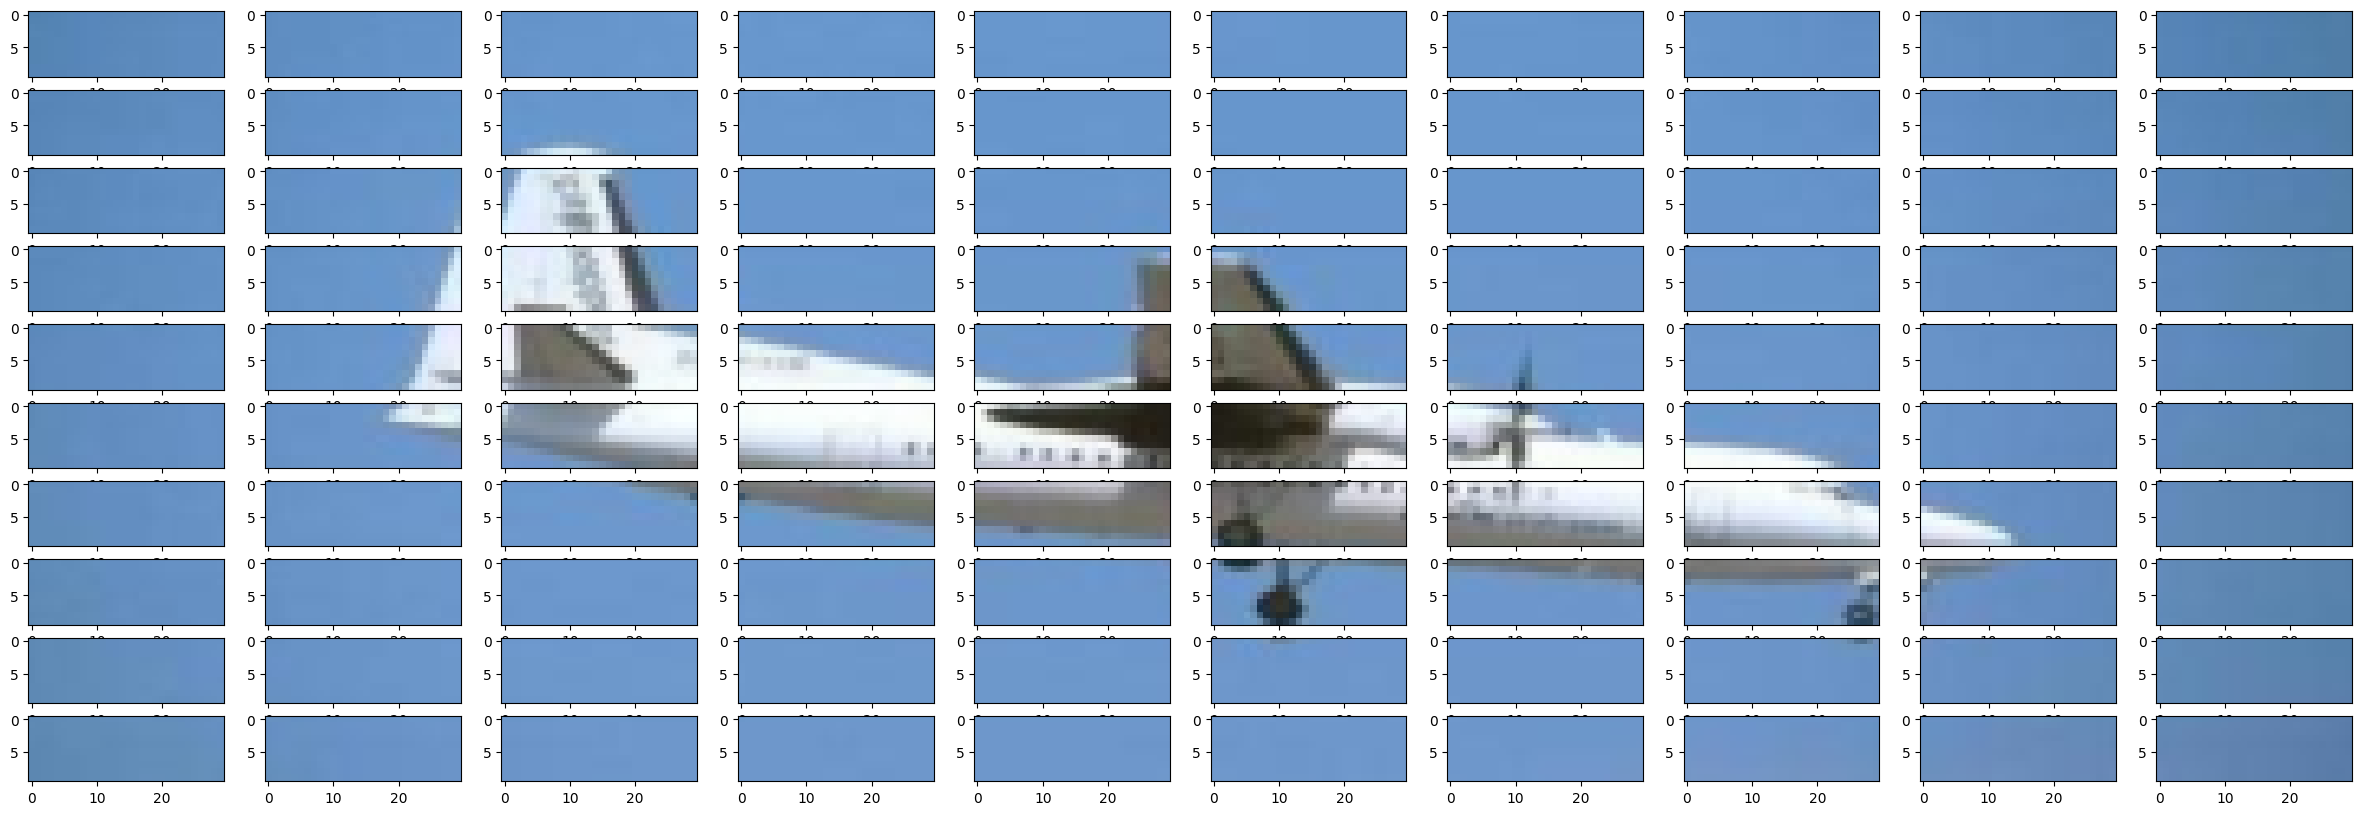

In [4]:
# Partition image into a 10x10 grid (each cell is 30x10).

from torchvision.transforms import transforms

import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

from utils.utilities import partition_to_grid

grid = partition_to_grid(image300x100, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

for i in range(10):
    for j in range(10):
        axes[i, j].imshow(transforms.ToPILImage()(grid[i][j]).convert('RGB'))

Length of color vector:  900


tensor([ 8.9897e+01,  3.4889e+00, -2.4072e+00,  1.3640e+02,  2.8739e+00,
        -1.4603e+00,  1.8663e+02,  4.2150e+00, -3.1892e+00,  9.7677e+01,
         1.9542e+00, -7.0156e-01,  1.4450e+02,  2.0905e+00, -1.4166e+00,
         1.9761e+02,  2.9357e+00, -1.8274e+00,  1.0281e+02,  1.2113e+00,
        -8.4661e-01,  1.4972e+02,  1.2287e+00, -9.0340e-01,  2.0376e+02,
         1.2086e+00, -8.7345e-01,  1.0421e+02,  9.0142e-01, -4.5008e-01,
         1.5121e+02,  9.0142e-01, -4.5011e-01,  2.0521e+02,  9.0142e-01,
        -4.5011e-01,  1.0385e+02,  6.9028e-01, -5.0728e-01,  1.5073e+02,
         7.2725e-01, -6.4199e-01,  2.0479e+02,  6.6630e-01, -5.4580e-01,
         1.0361e+02,  9.0765e-01,  1.0088e+00,  1.5009e+02,  5.9270e-01,
        -4.4114e-01,  2.0436e+02,  6.4581e-01,  6.9994e-01,  1.0263e+02,
         7.4428e-01, -4.6549e-01,  1.4963e+02,  7.4428e-01, -4.6549e-01,
         2.0363e+02,  7.4428e-01, -4.6549e-01,  9.9267e+01,  1.5151e+00,
        -7.0390e-01,  1.4549e+02,  2.2007e+00, -1.2

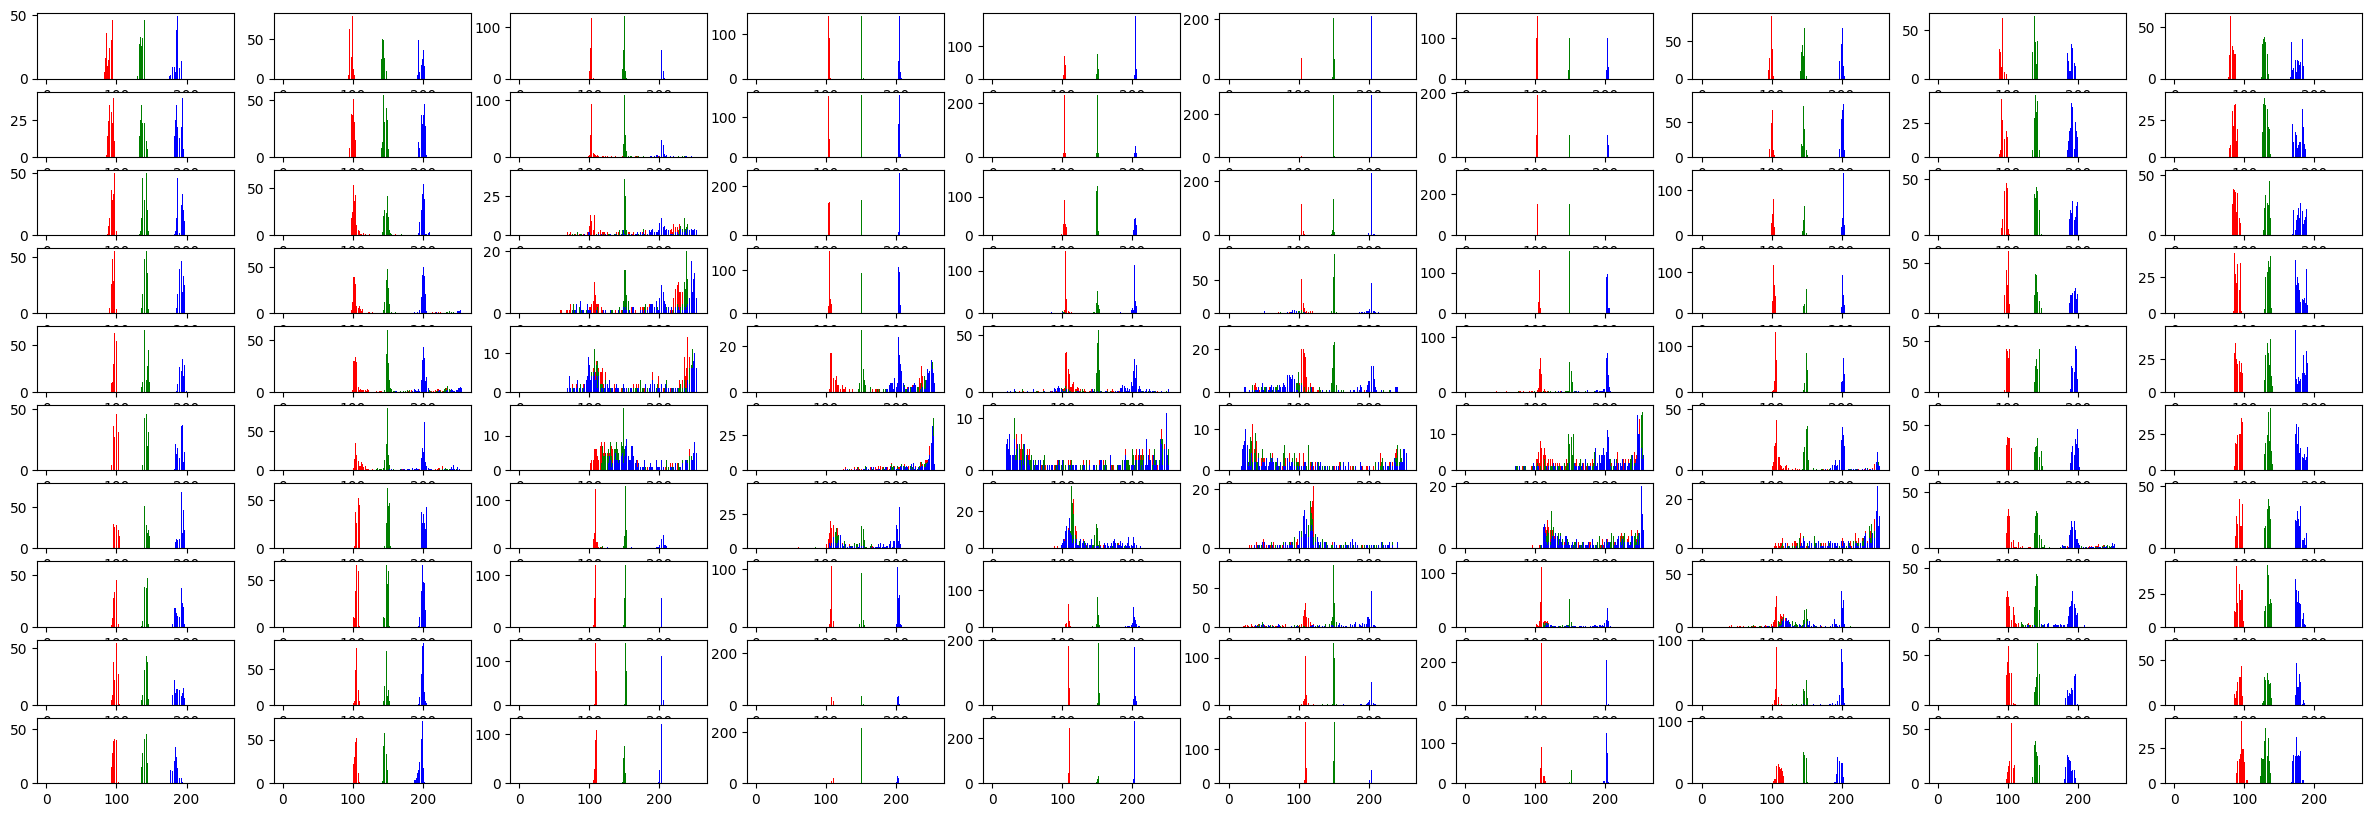

In [5]:
# Color moments (CM10x10).

# Color moments capture the distribution of intensities of each channel (R, G, B).
# In essense, we will be calculating the mean, standard deviation, and skewness of
# each 10x30 (HxW) grid cell of which there are 10x10, for each channel, of which there are 3.
# This results in a feature descriptor of length 10x10x3x3 = 900.

# Each cell tensor's shape is 3 x 10 x 30 (C x H x W)

import torch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

# Displaying histograms:
for i in range(len(grid)):
    for j in range(len(grid[0])):

        cell = grid[i][j]


        hist_red = torch.histc(cell[0].float(), bins=256, min=0, max=255)
        hist_green = torch.histc(cell[1].float(), bins=256, min=0, max=255)
        hist_blue = torch.histc(cell[2].float(), bins=256, min=0, max=255)

        axes[i, j].bar(range(256), hist_red, color='red')
        axes[i, j].bar(range(256), hist_green, color='green')
        axes[i, j].bar(range(256), hist_blue, color='blue')

# Represented as a 900-dim torch vector.
# The sequential vector representation is as follows:
#
# Row-major order of cells (10x10 cells), with each cell having 3 channel (RGB in that order),
# with each channel having 3 values (mean, standard deviation, skewness in that order).
#
# vec: [<cell_1 <red <mean, stdev, skew>>, <green <...>>, <blue <...>>>, <cell_2 ...>...]

from feature_extractors.color_moments import get_color_vector

color_vector = get_color_vector(grid)

print("Length of color vector: ", len(color_vector))
display(color_vector)


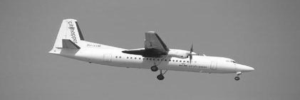

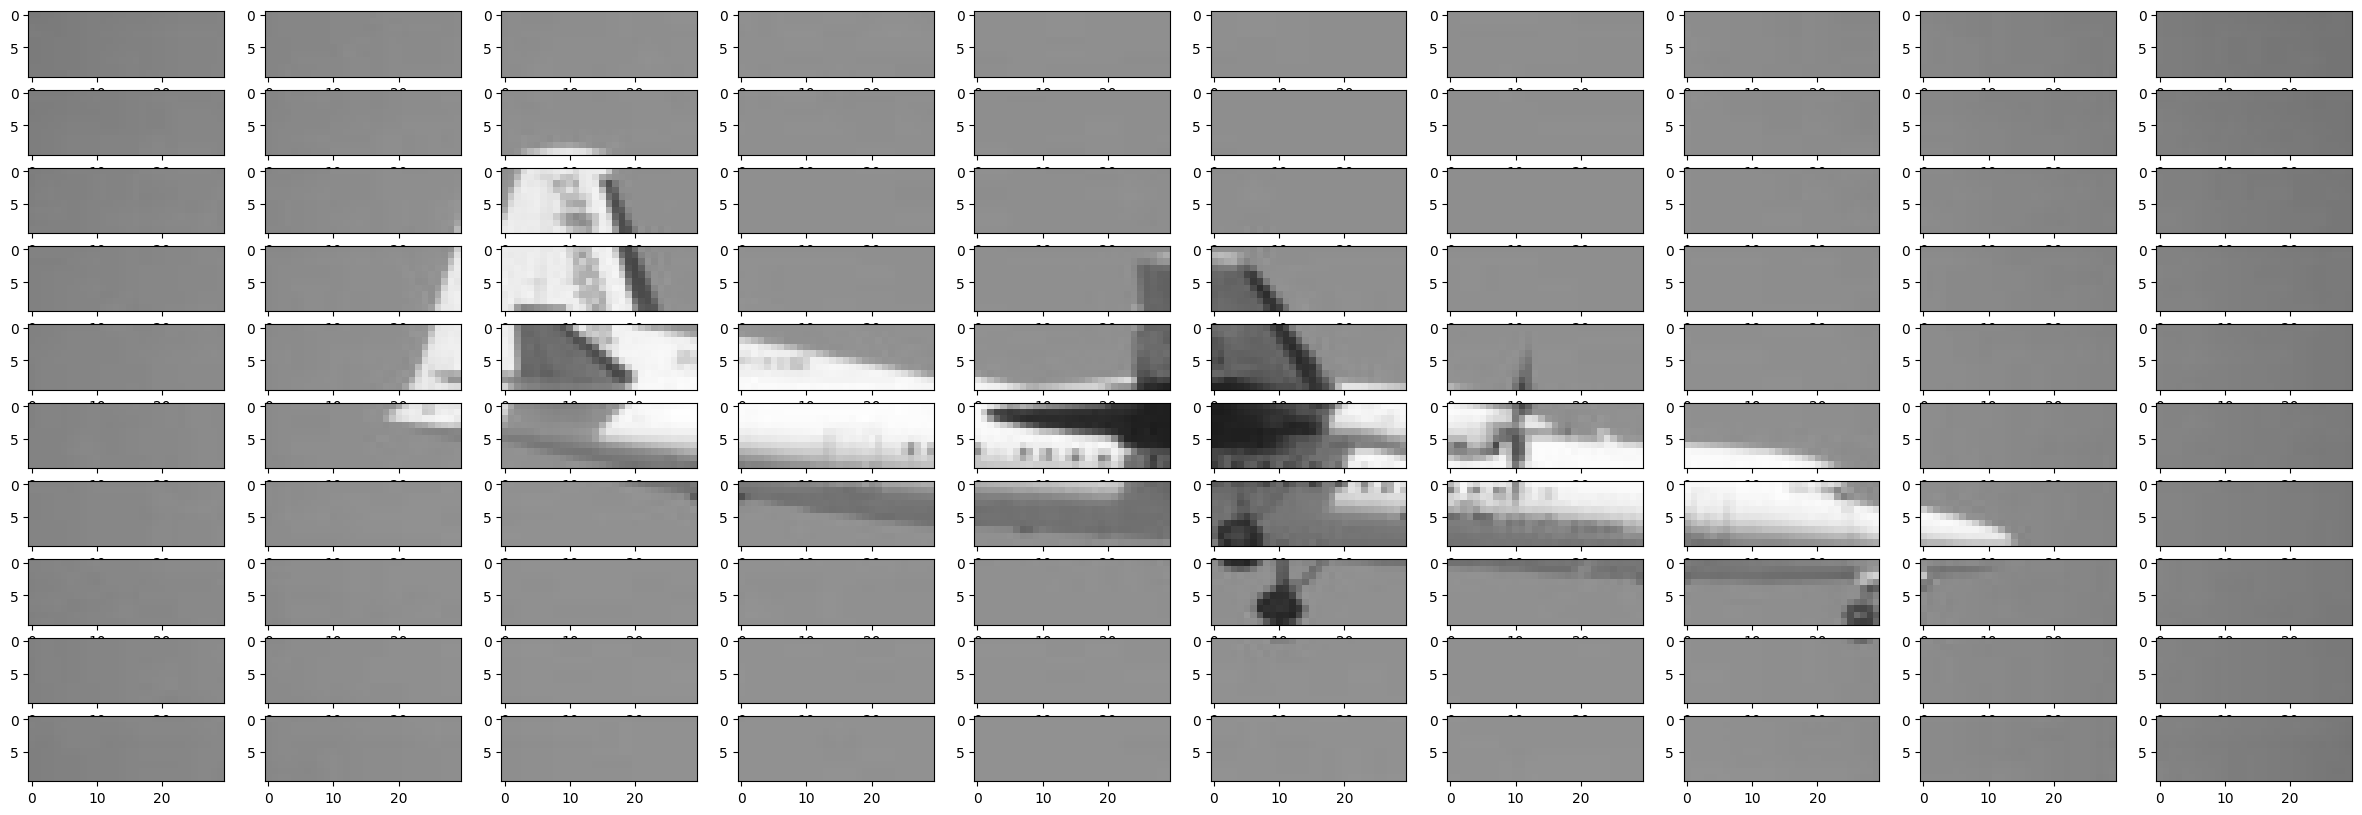

In [6]:
# Histograms of oriented gradients (HOG).

# Convert to grayscale.

from torchvision.transforms import Grayscale

gs_image = Grayscale()(image300x100)

display(gs_image)

# Convert to grid using previously defined function.

gs_grid = partition_to_grid(gs_image, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

for i in range(10):
    for j in range(10):
        axes[i, j].imshow(transforms.ToPILImage()(gs_grid[i][j]).convert('RGB'))

Length of HOG vector:  900


tensor([7.2585e+02, 2.0775e+02, 2.7707e+03, 9.9475e+02, 6.0516e+02, 6.0070e+02,
        9.9443e+02, 2.7561e+03, 1.7252e+02, 2.6881e+02, 1.9670e+02, 2.9469e+03,
        1.0843e+03, 6.4356e+02, 6.3407e+02, 1.0680e+03, 2.9336e+03, 1.8482e+02,
        2.8415e+02, 2.1015e+02, 3.0473e+03, 1.1252e+03, 6.5679e+02, 6.6092e+02,
        1.1238e+03, 3.0359e+03, 1.9075e+02, 7.1069e+02, 1.9876e+02, 3.0688e+03,
        1.1604e+03, 6.6523e+02, 6.6566e+02, 1.1604e+03, 3.0823e+03, 1.9387e+02,
        4.2129e+02, 1.8086e+02, 3.0489e+03, 1.1341e+03, 6.4798e+02, 6.5717e+02,
        1.1450e+03, 3.0630e+03, 1.8434e+02, 4.2129e+02, 1.7839e+02, 3.0217e+03,
        1.1281e+03, 6.5331e+02, 6.5437e+02, 1.1334e+03, 3.0343e+03, 1.8310e+02,
        0.0000e+00, 1.7695e+02, 3.0250e+03, 1.1363e+03, 6.5058e+02, 6.4404e+02,
        1.1353e+03, 3.0352e+03, 1.7695e+02, 4.1704e+02, 1.8490e+02, 2.9213e+03,
        1.1307e+03, 6.6651e+02, 6.5022e+02, 1.1207e+03, 2.9199e+03, 1.7839e+02,
        6.6619e+02, 1.7551e+02, 2.7545e+

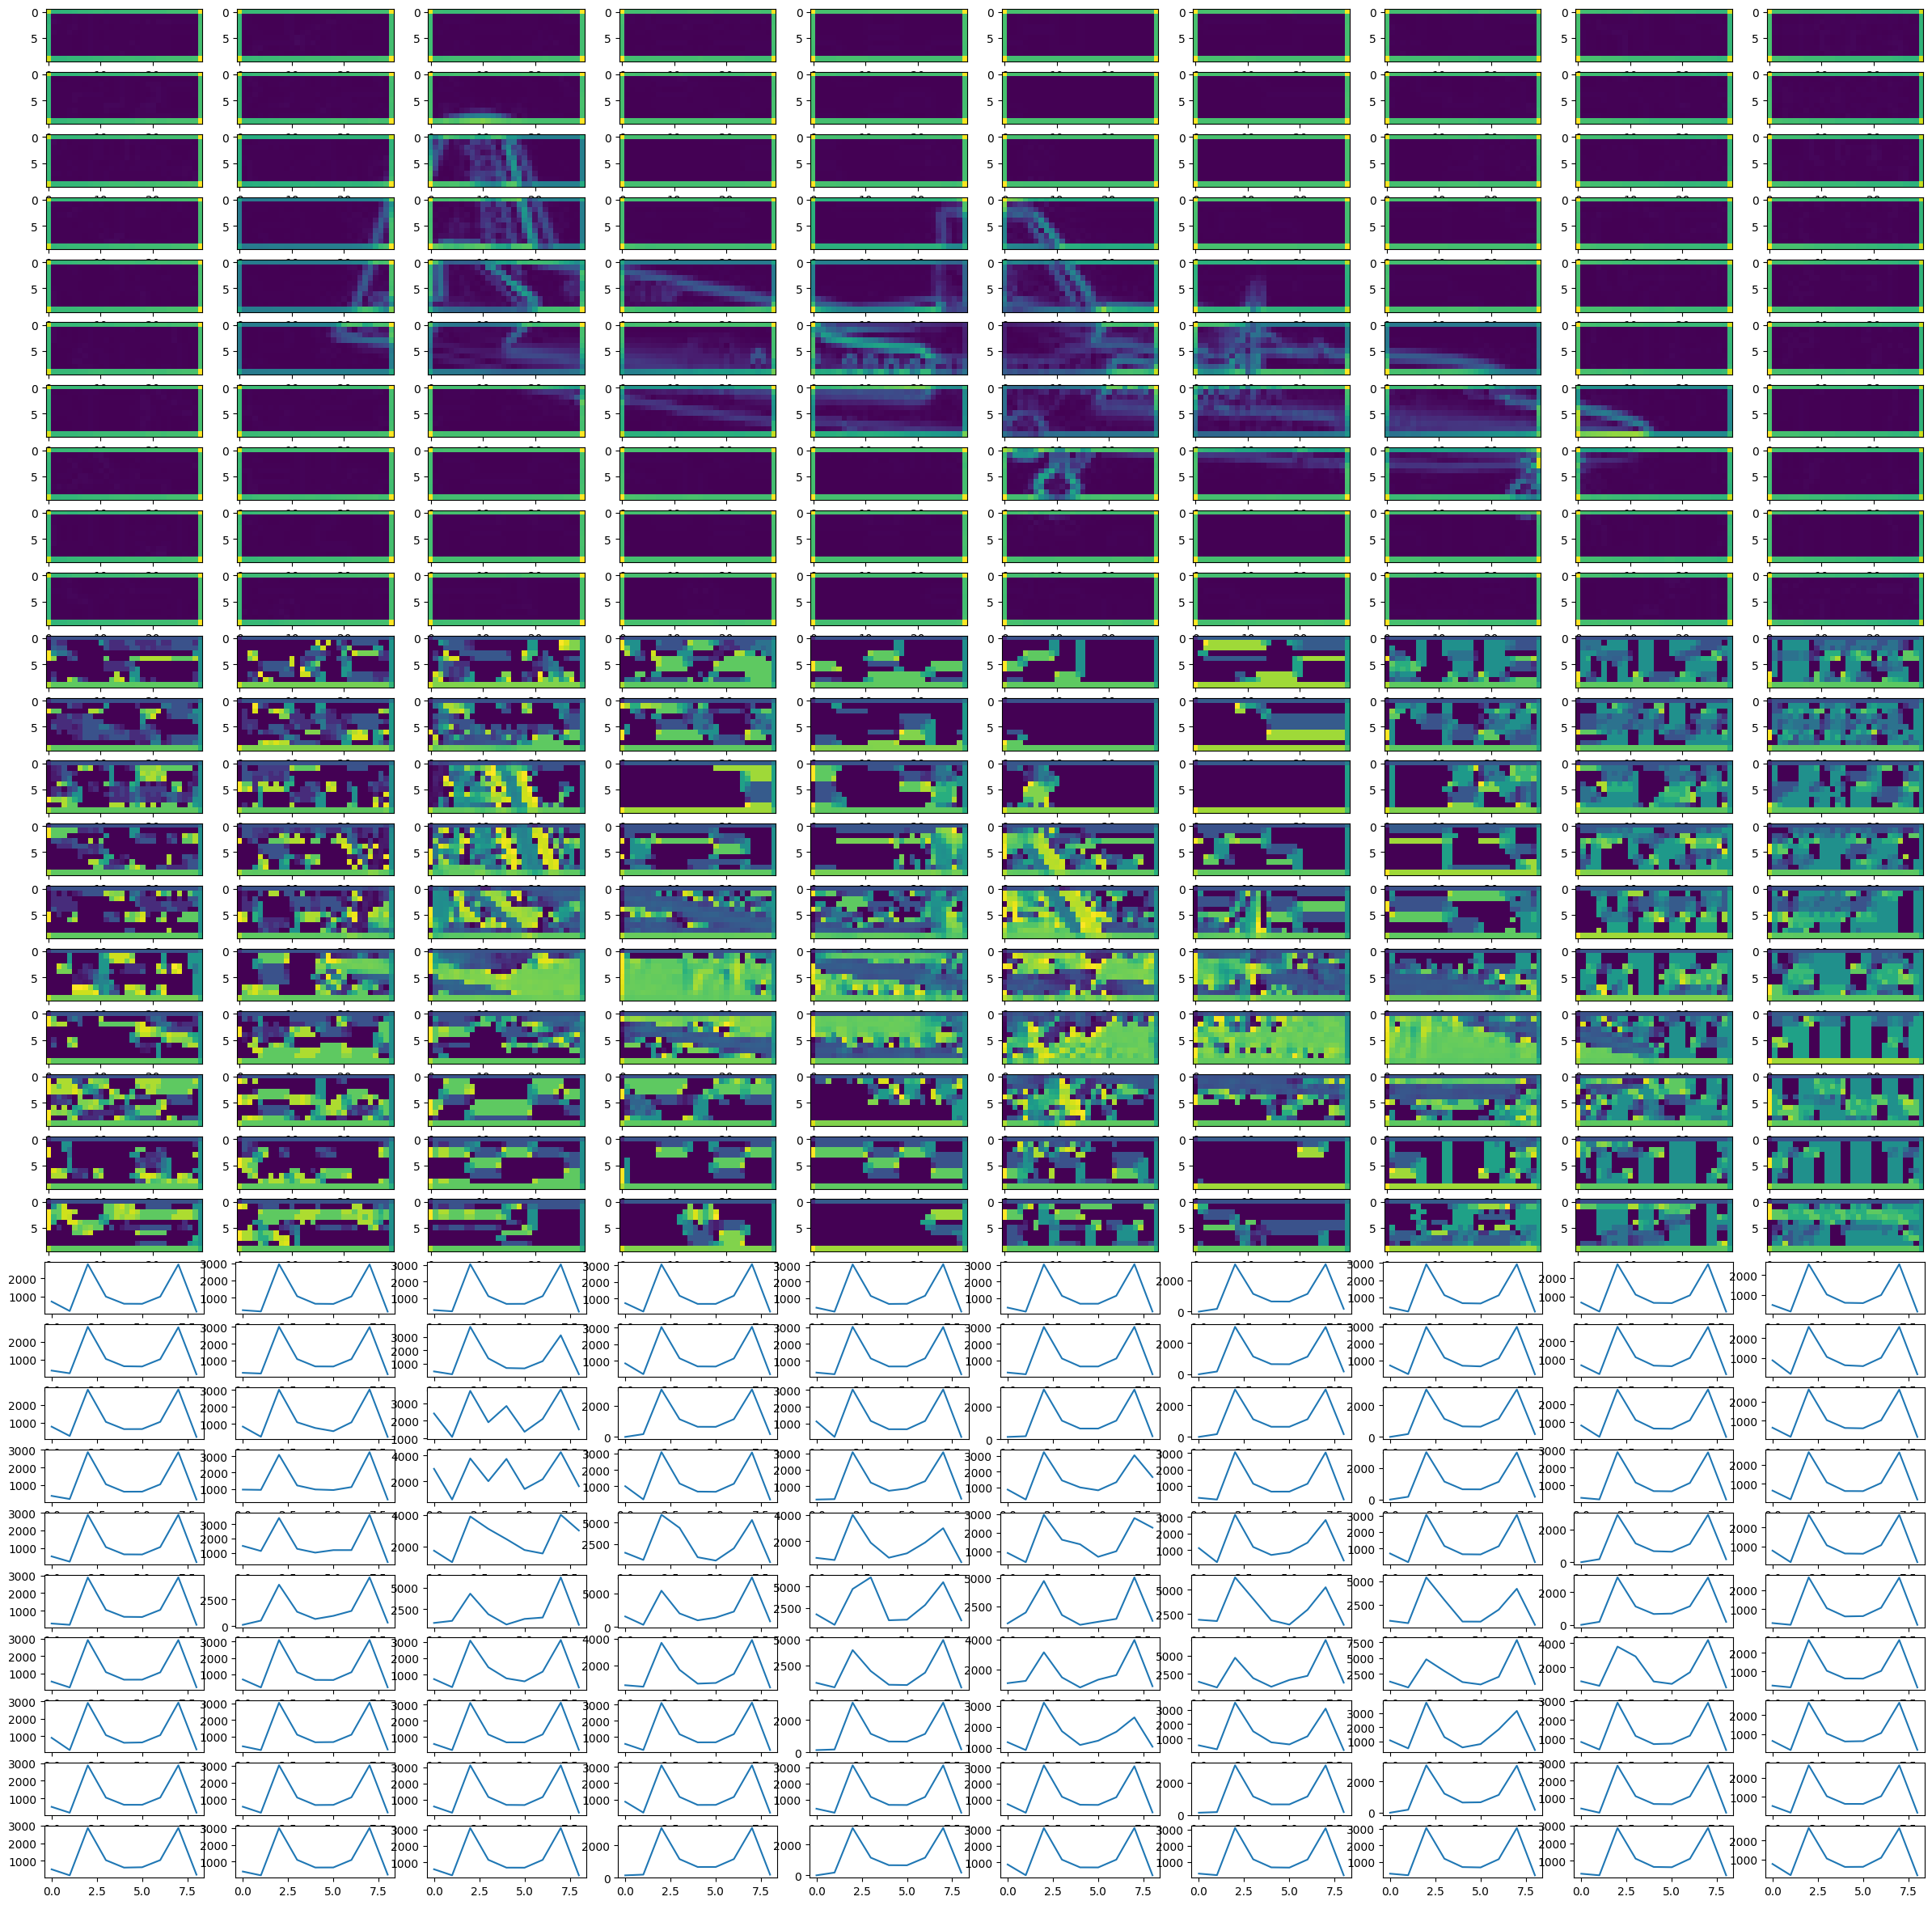

In [7]:
# 9 bin (signed) magnitude-weighted gradient histograms.
# Signed implies we consider 360 degrees, hence 9 bins => 40 degree bins.

from feature_extractors.HOG import get_hog_vector_from_bins, get_gradient_bins, get_gradients

g_mags, g_dirs = get_gradients(gs_grid)

gradient_bins = get_gradient_bins(g_mags, g_dirs)

hog_vector = get_hog_vector_from_bins(gradient_bins)


# Visualize gradient magnitude, dimentions and histograms.

fig, axes = plt.subplots(nrows=30, ncols=10, figsize=(30,30))

for i in range(len(g_mags)):
    for j in range(len(g_mags[0])):

        # Display magnitudes (on top third)
        axes[i, j].imshow(g_mags[i][j])
        # Display directions (middle third)
        axes[10 + i, j].imshow(g_dirs[i][j])
        # Display histogram of oriented gradients (on bottom third)
        axes[20 + i, j].plot(gradient_bins[i][j])

# Represent as a 900-dim torch vector.
# The sequential vector representation is as follows:
#
# Row-major order of cells (10x10 cells), with each cell having 9 values, one each
# for binned degrees: 0, 40, 80, 120, 160, 200, 240, 280, 320. 
# 0 is the same as 360.
# The magnitude of the gradient is distributed according to its direction,
# with the adjacent bins getting the magnitude weighted according to how
# close the direction is to the bin.
#
# vec: [<cell_1 <0, 40, 80, 120 ... 320>>, <cell_2 ...>...]

print("Length of HOG vector: ", len(hog_vector))
display(hog_vector)

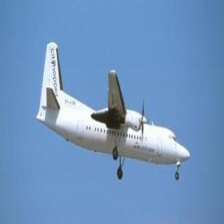

In [8]:
# Resize image to 224x224 and convert to float tensor.

image224x224 = Resize(size=(224, 224))(image)

display(image224x224)

img_tensor = transforms.Compose([transforms.ToTensor()])(image224x224)

In [9]:
# ResNet-50 Pretrained with default weights.

from feature_extractors.resnet_50 import get_resnet50_feature_vectors

avgpool_vector, layer3_vector, fc1000_vector = get_resnet50_feature_vectors(img_tensor)

print("\nLength of ResNet-AvgPool-1024 vector: ", len(avgpool_vector))
display(avgpool_vector)
print("\nLength of ResNet-Layer3-1024 vector: ", len(layer3_vector))
display(layer3_vector)
print("\nLength of ResNet-FC-1000 vector: ", len(fc1000_vector))
display(fc1000_vector)


Length of ResNet-AvgPool-1024 vector:  1024


tensor([0.0010, 0.0000, 0.0309,  ..., 0.0082, 0.0020, 0.0667])


Length of ResNet-Layer3-1024 vector:  1024


tensor([0.4269, 0.5923, 0.0199,  ..., 0.4957, 1.2389, 0.6401])


Length of ResNet-FC-1000 vector:  1000


tensor([ 2.8956e-01, -2.6062e-02,  7.2945e-02,  1.7968e-01,  3.0210e-01,
         3.1423e-01, -5.3550e-01, -3.2259e-01, -5.0023e-02, -1.5488e-01,
         4.0520e-01,  1.2216e-01,  6.3120e-02, -4.8385e-01,  4.6813e-03,
        -1.7243e-01,  1.3187e-01, -4.0014e-01, -3.1787e-01, -1.3161e-01,
         1.6554e-01,  7.5708e-01, -3.3281e-01, -2.0065e-01, -3.1411e-01,
        -1.7061e-02,  4.2554e-01,  1.7982e-02,  4.2411e-04,  5.4129e-01,
        -2.1067e-01, -9.2090e-02,  2.0929e-01,  7.8040e-02, -3.5075e-01,
         7.5325e-02,  1.1328e-01, -3.0864e-01,  4.3338e-01,  4.0567e-01,
        -6.2461e-02,  2.6916e-01,  1.1314e-01,  3.6250e-01,  3.1636e-01,
         2.4631e-02,  3.9040e-02,  6.1173e-01,  3.8112e-01, -1.0761e-01,
        -2.7528e-01,  3.3587e-01,  4.7960e-02, -2.1405e-01, -9.7369e-02,
        -3.8033e-02, -4.1286e-01, -2.0753e-01, -2.3805e-01,  2.6077e-01,
        -4.2284e-02, -1.1517e-01, -1.4148e-02, -8.6101e-02,  4.8937e-01,
         1.7208e-01,  4.8304e-01, -4.6816e-01,  2.6